# OOI Buoy QC Note
Revised May 28, 2026 by Sage Lichtenwalner

While investigating data from the Pioneer MAB Central mooring, I noticed that some of the data was flagged as suspect.  In an early prototype, AI suggested nulling out all data where temp or salinity had issues, which eliminated a lot of good data.  

There are two lessons here: never trust AI implicitly, and always look at the raw data.

Here is a quick summary.

In [12]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from erddapy import ERDDAP

## Load OOI Pioneer Data
First, let's load some near-surface CTD data from the Central Surface Mooring using erddapy.

In [13]:
# OOI Pioneer CP10CNSM – Near Surface Instrument Frame CTD
server = 'https://erddap.dataexplorer.oceanobservatories.org/erddap'
dataset_id = 'ooi-cp10cnsm-rid27-03-ctdbpc000'

start = '2025-01-01T00:00:00Z'
end = '2026-01-01T00:00:00Z'

variables = [
    'time',
    'sea_water_temperature',
    'sea_water_temperature_qc_agg',
    'sea_water_practical_salinity',
    'sea_water_practical_salinity_qc_agg',
    'latitude',
    'longitude',
]

constraints = {
    'time>=': start,
    'time<=': end,
}

e = ERDDAP(
    server=server,
    protocol='tabledap',
)
e.dataset_id = dataset_id
e.variables = variables
e.constraints = constraints

print(e.get_download_url(response='csvp'))

df = e.to_pandas(
    response='csv',
    parse_dates=True,
    skiprows=[1],
    index_col='time',
).dropna(how='all')

# Alternatively you can use the 'csvp' response format to get unit suffixes in column names.  But you may want to remove those for easier downstream use, as shown below.
# df = e.to_pandas(
#     response='csvp',
#     parse_dates=True,
#     skiprows=[0],
#     index_col='time (UTC)',
# ).dropna(how='all')
# # Remove unit suffixes from column names for easier downstream use.
# df.columns = [c.split(' (')[0] for c in df.columns]
# df.index.name = 'time'

print(f'Loaded {len(df):,} rows from {df.index.min()} to {df.index.max()}')
df.head()

https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-cp10cnsm-rid27-03-ctdbpc000.csvp?time,sea_water_temperature,sea_water_temperature_qc_agg,sea_water_practical_salinity,sea_water_practical_salinity_qc_agg,latitude,longitude&time>=1735689600.0&time<=1767225600.0
Loaded 137,424 rows from 2025-01-01 00:00:00+00:00 to 2026-01-01 00:00:00+00:00


,sea_water_temperature,sea_water_temperature_qc_agg,sea_water_practical_salinity,sea_water_practical_salinity_qc_agg,latitude,longitude
time,,,,,,
2025-01-01 00:00:00+00:00,11.643658,1,33.373315,1,35.950317,-75.11953
2025-01-01 00:02:00+00:00,11.642210,1,33.360807,1,35.950317,-75.11953
2025-01-01 00:03:00+00:00,11.671196,1,33.411328,1,35.950317,-75.11953
2025-01-01 00:15:00+00:00,11.589437,1,33.270471,1,35.950317,-75.11953
2025-01-01 00:16:00+00:00,11.623095,1,33.331542,1,35.950317,-75.11953


### Quickplot of the Pioneer CTD

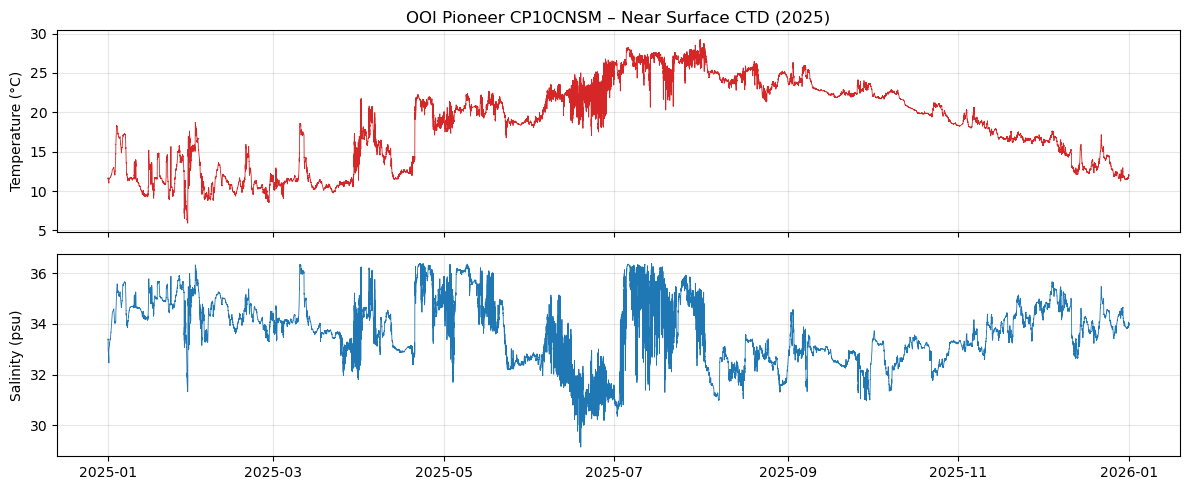

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(df.index, df['sea_water_temperature'], color='tab:red', lw=0.6)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('OOI Pioneer CP10CNSM – Near Surface CTD (2025)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['sea_water_practical_salinity'], color='tab:blue', lw=0.6)
axes[1].set_ylabel('Salinity (psu)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Quartod Flags

Now, let's take a quick look at the QC Flags in this dataset.  We'll create a quick table showing the count of data points for each flag for each variable.

In [15]:
# Compact QC summary table: counts and percentages by aggregate flag
qc_temp = (
    df['sea_water_temperature_qc_agg']
    .value_counts(dropna=False)
    .sort_index()
    .rename('temp_count')
)
qc_sal = (
    df['sea_water_practical_salinity_qc_agg']
    .value_counts(dropna=False)
    .sort_index()
    .rename('sal_count')
)

qc_summary = pd.concat([qc_temp, qc_sal], axis=1).fillna(0).astype(int)
qc_summary.index.name = 'flag'
qc_summary['temp_pct'] = np.round(100 * qc_summary['temp_count'] / len(df),2)
qc_summary['sal_pct'] = np.round(100 * qc_summary['sal_count'] / len(df),2)

qc_summary

,temp_count,sal_count,temp_pct,sal_pct
flag,,,,
1,137424,129521,100.0,94.25
3,0,7903,0.0,5.75


Next we'll plot the raw data in black, and overlay it with the data that "passed" in color.

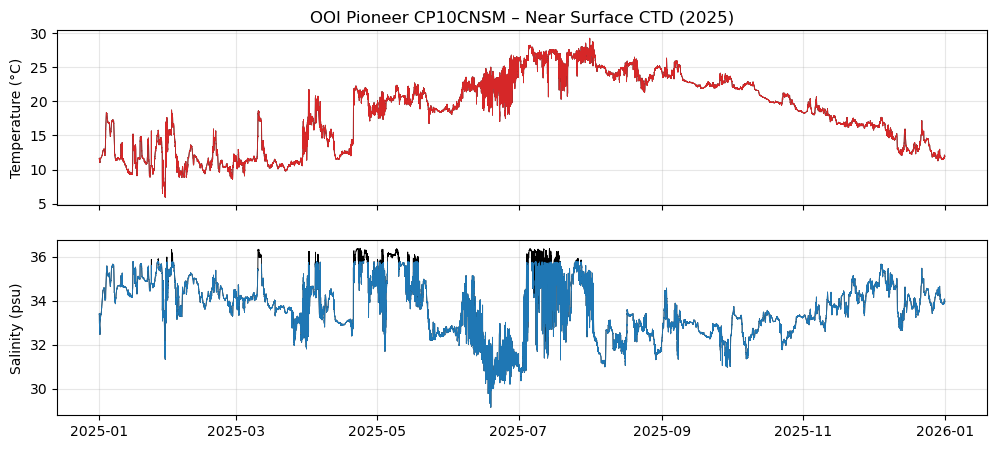

In [16]:
# QARTOD QC Flags
# 1=Passed, 2=not-evaluated, 3=suspect 
accepted_flags = [1, 2]
temp_ok = df['sea_water_temperature_qc_agg'].isin(accepted_flags)
sal_ok = df['sea_water_practical_salinity_qc_agg'].isin(accepted_flags)

df_plot = df.copy()
df_plot.loc[~temp_ok, 'sea_water_temperature'] = np.nan
df_plot.loc[~sal_ok, 'sea_water_practical_salinity'] = np.nan

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(df.index, df['sea_water_temperature'], color='k', lw=0.6)
axes[0].plot(df_plot.index, df_plot['sea_water_temperature'], color='tab:red', lw=0.6)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('OOI Pioneer CP10CNSM – Near Surface CTD (2025)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['sea_water_practical_salinity'], color='k', lw=0.6)
axes[1].plot(df_plot.index, df_plot['sea_water_practical_salinity'], color='tab:blue', lw=0.6)
axes[1].set_ylabel('Salinity (psu)')
axes[1].grid(True, alpha=0.3)



### Summary

Based on this, we can see that all of the temperature data currently passes, but there is a lot of "suspect" salinity data.  

However, it appears that this data is suspect because the maximum salinity threshold may be set too low for this mooring.  

Otherwise, the data all looks good.  So we can ignore the QC flags for this time range.  And we definitely shouldn't null out good temperature data based on the salinity flags.